In [28]:
# Importing Libraries
import ast
import seaborn as sns
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [63]:
df_DA_IRE = df[(df['job_title'] == 'Data Scientist') & (df['job_country'] == 'Ireland')].copy()

In [64]:
df_DA_IRE['job_posted_month_no'] = df_DA_IRE['job_posted_date'].dt.month

In [65]:
df_DA_IRE_explode = df_DA_IRE.explode('job_skills')

In [66]:
df_DA_IRE_pivot = df_DA_IRE_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

df_DA_IRE_pivot.loc['Total'] = df_DA_IRE_pivot.sum()

df_DA_IRE_pivot = df_DA_IRE_pivot[df_DA_IRE_pivot.loc['Total'].sort_values(ascending=False).index]

df_DA_IRE_pivot = df_DA_IRE_pivot.drop('Total')

df_DA_IRE_pivot

job_skills,python,sql,r,tableau,power bi,aws,hadoop,sas,spark,azure,...,github,golang,opencv,outlook,sharepoint,redshift,swift,unix,visio,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,40,32,24,20,2,6,8,10,6,10,...,0,0,0,0,1,0,0,0,0,0
2,23,23,14,17,8,3,4,10,3,6,...,1,0,0,0,0,0,0,0,0,0
3,27,18,14,12,12,12,1,0,6,7,...,0,0,1,1,0,0,0,0,0,0
4,24,16,9,4,2,7,5,2,5,4,...,0,0,0,0,0,1,0,0,0,0
5,32,35,26,16,15,5,10,8,7,4,...,0,0,0,0,0,0,0,0,0,0
6,26,19,15,5,3,9,9,0,3,2,...,0,0,0,0,0,0,0,0,0,0
7,25,16,18,6,6,4,6,2,5,2,...,0,0,0,0,0,0,0,0,0,1
8,15,14,10,8,5,1,4,2,3,1,...,0,1,0,0,0,0,0,1,0,0
9,4,4,3,2,2,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0


<Axes: xlabel='job_posted_month_no'>

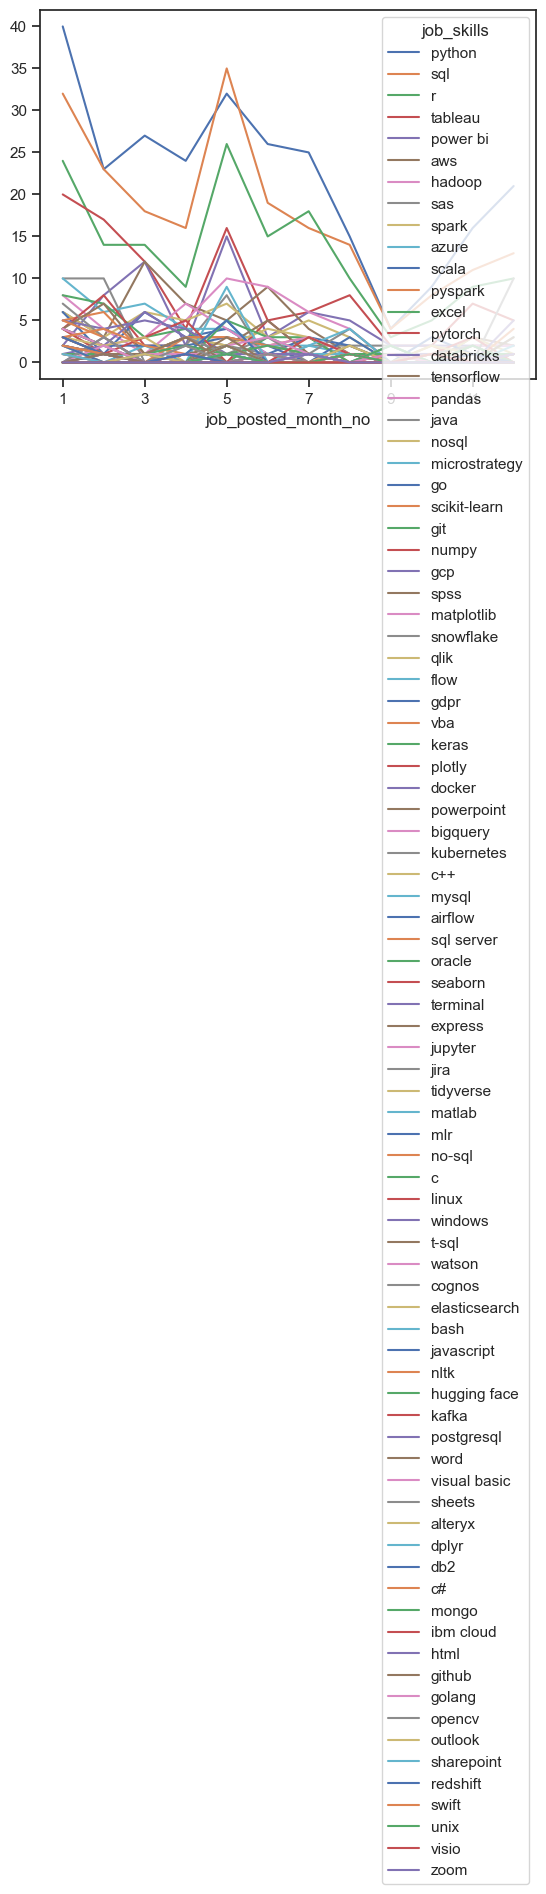

In [67]:
df_DA_IRE_pivot.plot(kind='line')

In [68]:
DA_totals = df_DA_IRE.groupby('job_posted_month_no').size()

In [69]:
df_DA_IRE_percent = df_DA_IRE_pivot.div(DA_totals/100, axis=0)

df_DA_IRE_percent

job_skills,python,sql,r,tableau,power bi,aws,hadoop,sas,spark,azure,...,github,golang,opencv,outlook,sharepoint,redshift,swift,unix,visio,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,52.631579,42.105263,31.578947,26.315789,2.631579,7.894737,10.526316,13.157895,7.894737,13.157895,...,0.000000,0.000000,0.000,0.000,1.315789,0.000000,0.000000,0.000000,0.000000,0.000000
2,63.888889,63.888889,38.888889,47.222222,22.222222,8.333333,11.111111,27.777778,8.333333,16.666667,...,2.777778,0.000000,0.000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,84.375000,56.250000,43.750000,37.500000,37.500000,37.500000,3.125000,0.000000,18.750000,21.875000,...,0.000000,0.000000,3.125,3.125,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,82.758621,55.172414,31.034483,13.793103,6.896552,24.137931,17.241379,6.896552,17.241379,13.793103,...,0.000000,0.000000,0.000,0.000,0.000000,3.448276,0.000000,0.000000,0.000000,0.000000
5,72.727273,79.545455,59.090909,36.363636,34.090909,11.363636,22.727273,18.181818,15.909091,9.090909,...,0.000000,0.000000,0.000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,78.787879,57.575758,45.454545,15.151515,9.090909,27.272727,27.272727,0.000000,9.090909,6.060606,...,0.000000,0.000000,0.000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,71.428571,45.714286,51.428571,17.142857,17.142857,11.428571,17.142857,5.714286,14.285714,5.714286,...,0.000000,0.000000,0.000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,2.857143
8,65.217391,60.869565,43.478261,34.782609,21.739130,4.347826,17.391304,8.695652,13.043478,4.347826,...,0.000000,4.347826,0.000,0.000,0.000000,0.000000,0.000000,4.347826,0.000000,0.000000
9,66.666667,66.666667,50.000000,33.333333,33.333333,0.000000,0.000000,33.333333,0.000000,0.000000,...,0.000000,0.000000,0.000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [70]:
# changes month number to month name
df_DA_IRE_percent = df_DA_IRE_percent.reset_index()
df_DA_IRE_percent['job_posted_month'] = df_DA_IRE_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_IRE_percent = df_DA_IRE_percent.set_index('job_posted_month')
df_DA_IRE_percent = df_DA_IRE_percent.drop(columns='job_posted_month_no')

df_DA_IRE_percent

job_skills,python,sql,r,tableau,power bi,aws,hadoop,sas,spark,azure,...,github,golang,opencv,outlook,sharepoint,redshift,swift,unix,visio,zoom
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,52.631579,42.105263,31.578947,26.315789,2.631579,7.894737,10.526316,13.157895,7.894737,13.157895,...,0.000000,0.000000,0.000,0.000,1.315789,0.000000,0.000000,0.000000,0.000000,0.000000
Feb,63.888889,63.888889,38.888889,47.222222,22.222222,8.333333,11.111111,27.777778,8.333333,16.666667,...,2.777778,0.000000,0.000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,84.375000,56.250000,43.750000,37.500000,37.500000,37.500000,3.125000,0.000000,18.750000,21.875000,...,0.000000,0.000000,3.125,3.125,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Apr,82.758621,55.172414,31.034483,13.793103,6.896552,24.137931,17.241379,6.896552,17.241379,13.793103,...,0.000000,0.000000,0.000,0.000,0.000000,3.448276,0.000000,0.000000,0.000000,0.000000
May,72.727273,79.545455,59.090909,36.363636,34.090909,11.363636,22.727273,18.181818,15.909091,9.090909,...,0.000000,0.000000,0.000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jun,78.787879,57.575758,45.454545,15.151515,9.090909,27.272727,27.272727,0.000000,9.090909,6.060606,...,0.000000,0.000000,0.000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jul,71.428571,45.714286,51.428571,17.142857,17.142857,11.428571,17.142857,5.714286,14.285714,5.714286,...,0.000000,0.000000,0.000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,2.857143
Aug,65.217391,60.869565,43.478261,34.782609,21.739130,4.347826,17.391304,8.695652,13.043478,4.347826,...,0.000000,4.347826,0.000,0.000,0.000000,0.000000,0.000000,4.347826,0.000000,0.000000
Sep,66.666667,66.666667,50.000000,33.333333,33.333333,0.000000,0.000000,33.333333,0.000000,0.000000,...,0.000000,0.000000,0.000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


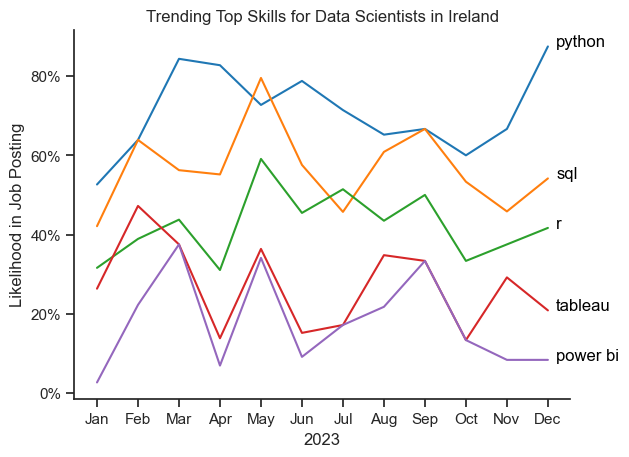

In [72]:
df_plot = df_DA_IRE_percent.iloc[:, :5]

sns.lineplot(data=df_plot, dashes=False, legend='full', palette='tab10')
sns.set_theme(style='ticks')
sns.despine() 

plt.title('Trending Top Skills for Data Scientists in Ireland')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

# annotate the plot with the top 5 skills using plt.text()
for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i], color='black')

plt.show()